# Grounding-line position sweep

This notebook compares a small sweep in grounding-line offset at **10 Hz**.

Interpretation used here: a positive `delta_x_m` means the grounding line moved to `+x` relative to a fixed field array and source. In the forward models that is emulated by shifting the **source and receiver coordinates** left by the same amount while keeping the reflector fixed at `x = 0`. That preserves the same relative source/receiver/reflector geometry without rebuilding the mesh.

The key diagnostic in this notebook is whether the recovered offset curve follows the 1:1 line. If it does not, that indicates the present 10 Hz configuration is not resolving grounding-line position cleanly with this workflow.

In [1]:
from csv import DictReader
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
summary_path = ROOT / 'results_glposition_10hz' / 'summary.csv'
requested_delta_x = np.asarray([0.0, 1.0, 10.0, 100.0])
rayleigh_speed_mps = 1900.0

def load_rows(path):
    with path.open() as handle:
        return list(DictReader(handle))

rows = sorted(load_rows(summary_path), key=lambda row: float(row['delta_x_m']))
completed_delta_x = np.asarray([float(row['delta_x_m']) for row in rows])
pending_delta_x = [dx for dx in requested_delta_x if dx not in set(completed_delta_x)]

print(f'Loaded {len(rows)} completed grounding-line position cases')
print('Completed offsets:', completed_delta_x.tolist())
print('Pending offsets:', pending_delta_x if pending_delta_x else 'none')
rows

Loaded 4 completed grounding-line position cases
Completed offsets: [0.0, 1.0, 10.0, 100.0]
Pending offsets: none


[{'case_id': 'dx0000m',
  'geometry': 'supported_cavity_100m',
  'source_frequency_hz': '10.0',
  'delta_x_m': '0.0',
  'coordinate_shift_m': '-0.0',
  'source_x_m': '-10000.0',
  'array_x_start_m': '-2000.0',
  'array_x_end_m': '2000.0',
  'nstations': '638',
  'reflection_coefficient': '-0.02266959419393221',
  'correlation': '-0.8602808777183051',
  'alignment_lag_s': '0.03679999999999595',
  'incident_center_s': '4.982',
  'reflected_center_s': '5.6172'},
 {'case_id': 'dx0001m',
  'geometry': 'supported_cavity_100m',
  'source_frequency_hz': '10.0',
  'delta_x_m': '1.0',
  'coordinate_shift_m': '-1.0',
  'source_x_m': '-10001.0',
  'array_x_start_m': '-2001.0',
  'array_x_end_m': '1999.0',
  'nstations': '638',
  'reflection_coefficient': '-0.02252072984394556',
  'correlation': '-0.8655129710037744',
  'alignment_lag_s': '0.035999999999996035',
  'incident_center_s': '4.9828',
  'reflected_center_s': '5.6176'},
 {'case_id': 'dx0010m',
  'geometry': 'supported_cavity_100m',
  'sour

In [2]:
delta_x = np.asarray([float(row['delta_x_m']) for row in rows])
reflection = np.asarray([float(row['reflection_coefficient']) for row in rows])
correlation = np.asarray([float(row['correlation']) for row in rows])
alignment_lag = np.asarray([float(row.get('alignment_lag_s', 0.0)) for row in rows])
incident_center = np.asarray([float(row['incident_center_s']) for row in rows])
reflected_center = np.asarray([float(row['reflected_center_s']) for row in rows])
packet_separation = reflected_center - incident_center
baseline_sep = packet_separation[np.argmin(delta_x)]
delta_x_est = 0.5 * rayleigh_speed_mps * (packet_separation - baseline_sep)
delta_x_error = delta_x_est - delta_x

for row, sep, dx_est in zip(rows, packet_separation, delta_x_est):
    print(
        f"{row['case_id']:>8s}  true Δx={float(row['delta_x_m']):7.2f} m  "
        f"R={float(row['reflection_coefficient']): .5f}  corr={float(row['correlation']): .3f}  "
        f"(t_ref - t_inc)={sep: .4f} s  Δx_est={dx_est: .2f} m"
    )

 dx0000m  true Δx=   0.00 m  R=-0.02267  corr=-0.860  (t_ref - t_inc)= 0.6352 s  Δx_est= 0.00 m
 dx0001m  true Δx=   1.00 m  R=-0.02252  corr=-0.866  (t_ref - t_inc)= 0.6348 s  Δx_est=-0.38 m
 dx0010m  true Δx=  10.00 m  R=-0.02297  corr=-0.854  (t_ref - t_inc)= 0.6376 s  Δx_est= 2.28 m
 dx0100m  true Δx= 100.00 m  R= 0.02341  corr= 0.875  (t_ref - t_inc)= 0.6340 s  Δx_est=-1.14 m


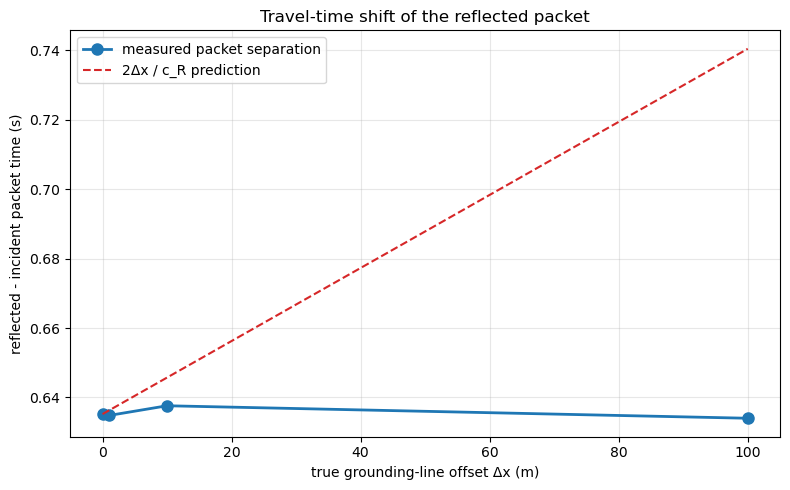

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(delta_x, packet_separation, 'o-', lw=2, ms=8, label='measured packet separation')
theory = baseline_sep + 2.0 * delta_x / rayleigh_speed_mps
ax.plot(delta_x, theory, '--', lw=1.5, color='tab:red', label='2Δx / c_R prediction')
if pending_delta_x:
    ax.scatter(pending_delta_x, baseline_sep + 2.0 * np.asarray(pending_delta_x) / rayleigh_speed_mps, marker='x', s=80, color='gray', label='requested but pending')
ax.set_xlabel('true grounding-line offset Δx (m)')
ax.set_ylabel('reflected - incident packet time (s)')
ax.set_title('Travel-time shift of the reflected packet')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

true Δx =    0.00 m   recovered =    0.00 m   error =  0.00 m
true Δx =    1.00 m   recovered =   -0.38 m   error = -1.38 m
true Δx =   10.00 m   recovered =    2.28 m   error = -7.72 m
true Δx =  100.00 m   recovered =   -1.14 m   error = -101.14 m


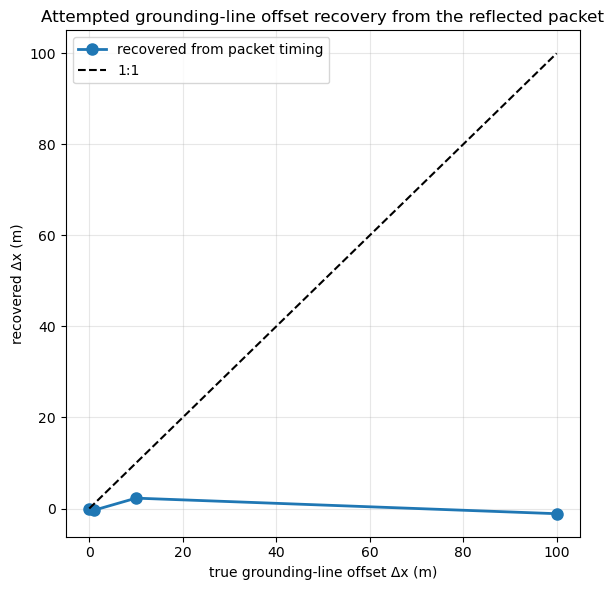

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(delta_x, delta_x_est, 'o-', lw=2, ms=8, label='recovered from packet timing')
line_max = max(requested_delta_x.max(), np.nanmax(delta_x_est) if len(delta_x_est) else 0.0)
ax.plot([0, line_max], [0, line_max], 'k--', lw=1.5, label='1:1')
ax.set_xlabel('true grounding-line offset Δx (m)')
ax.set_ylabel('recovered Δx (m)')
ax.set_title('Attempted grounding-line offset recovery from the reflected packet')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

for dx_true, dx_rec, err in zip(delta_x, delta_x_est, delta_x_error):
    print(f'true Δx = {dx_true:7.2f} m   recovered = {dx_rec:7.2f} m   error = {err: .2f} m')

In [5]:
rms_error = np.sqrt(np.mean(delta_x_error**2)) if len(delta_x_error) else np.nan
max_abs_error = np.max(np.abs(delta_x_error)) if len(delta_x_error) else np.nan
print(f'RMS recovery error = {rms_error:.2f} m')
print(f'Maximum absolute error = {max_abs_error:.2f} m')
if np.all(np.abs(delta_x_error) < 0.25 * np.maximum(1.0, delta_x)):
    print('The imposed grounding-line offsets are recovered reasonably well in this configuration.')
else:
    print('The imposed grounding-line offsets are not recovered cleanly at 10 Hz with the current geometry and picking workflow.')

RMS recovery error = 50.72 m
Maximum absolute error = 101.14 m
The imposed grounding-line offsets are not recovered cleanly at 10 Hz with the current geometry and picking workflow.


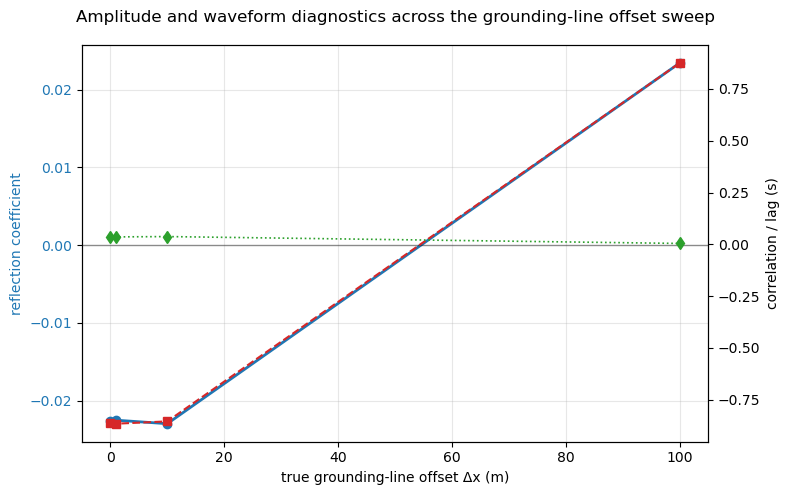

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(delta_x, reflection, 'o-', color='tab:blue', lw=2, label='reflection coefficient')
ax1.axhline(0.0, color='k', lw=1.0, alpha=0.4)
ax1.set_xlabel('true grounding-line offset Δx (m)')
ax1.set_ylabel('reflection coefficient', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(delta_x, correlation, 's--', color='tab:red', lw=1.5, label='correlation')
ax2.plot(delta_x, alignment_lag, 'd:', color='tab:green', lw=1.2, label='alignment lag')
ax2.set_ylabel('correlation / lag (s)')
fig.suptitle('Amplitude and waveform diagnostics across the grounding-line offset sweep')
fig.tight_layout()

Text(0.5, 0, 'time (s)')

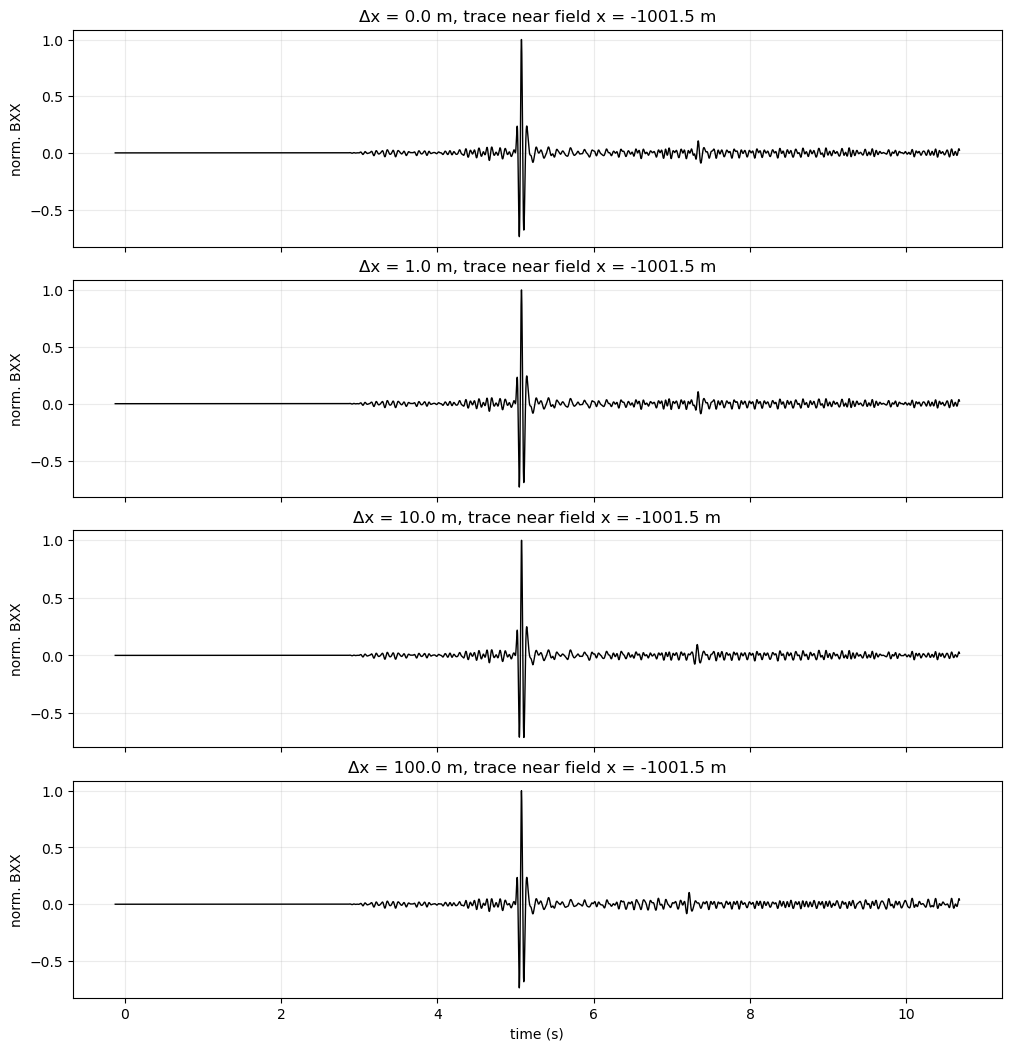

In [7]:
def load_gather(case_id):
    path = ROOT / 'results_glposition_10hz' / case_id / 'surface_gather.npz'
    data = np.load(path, allow_pickle=True)
    return {key: data[key] for key in data.files}

def field_x(gather, row):
    return gather['x'] - float(row['coordinate_shift_m'])

def trace_at_field_x(gather, row, x_target):
    x_field = field_x(gather, row)
    idx = int(np.argmin(np.abs(x_field - x_target)))
    return x_field[idx], gather['bxx'][idx, :]

selected_x = -1000.0
fig, axes = plt.subplots(len(rows), 1, figsize=(10, 2.6 * len(rows)), sharex=True, constrained_layout=True)
for ax, row in zip(np.atleast_1d(axes), rows):
    gather = load_gather(row['case_id'])
    x_used, trace = trace_at_field_x(gather, row, selected_x)
    trace = trace / max(np.max(np.abs(trace)), 1e-12)
    ax.plot(gather['time'], trace, color='black', lw=1.0)
    ax.set_title(f"Δx = {float(row['delta_x_m']):.1f} m, trace near field x = {x_used:.1f} m")
    ax.grid(True, alpha=0.25)
    ax.set_ylabel('norm. BXX')
    # ax.set_xlim([6,8])
axes[-1].set_xlabel('time (s)')

Text(0.5, 0.98, 'Surface gathers mapped back to the common field coordinate frame')

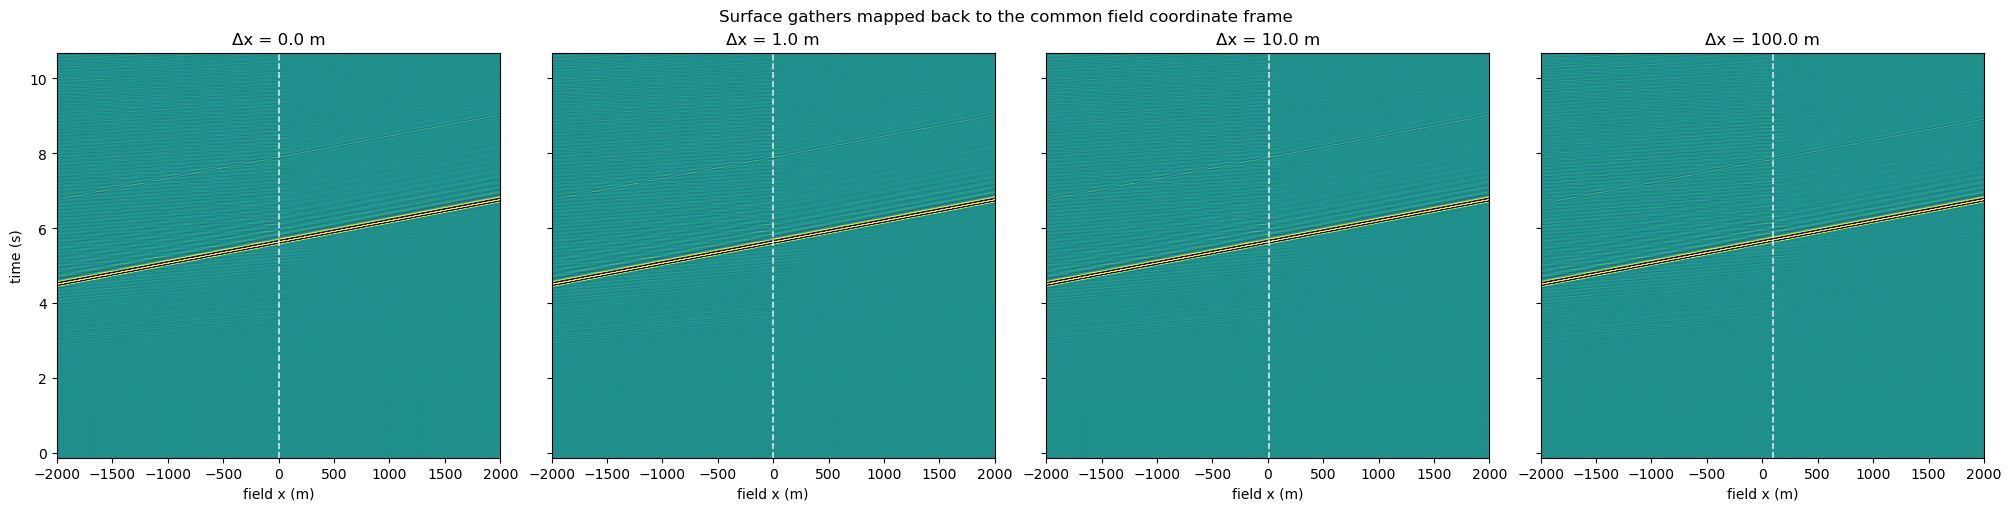

In [8]:
fig, axes = plt.subplots(1, len(rows), figsize=(5 * max(1, len(rows)), 5), sharey=True, constrained_layout=True)
for ax, row in zip(np.atleast_1d(axes), rows):
    gather = load_gather(row['case_id'])
    x_field = field_x(gather, row)
    clip = np.percentile(np.abs(gather['bxx']), 99)
    ax.imshow(
        gather['bxx'].T,
        origin='lower',
        aspect='auto',
        extent=[x_field.min(), x_field.max(), gather['time'].min(), gather['time'].max()],
        vmin=-clip, vmax=clip,
    )
    ax.axvline(float(row['delta_x_m']), color='w', ls='--', lw=1.2, alpha=0.8)
    ax.set_title(f"Δx = {float(row['delta_x_m']):.1f} m")
    ax.set_xlabel('field x (m)')
axes[0].set_ylabel('time (s)')
fig.suptitle('Surface gathers mapped back to the common field coordinate frame')